# YOLO Label to Mask Conversion Pipeline

This notebook converts YOLO format bounding box labels into binary segmentation masks. It provides a reverse pipeline that allows visualizing and validating YOLO annotations as visual masks.

## 🎯 Pipeline Overview

1. **Import Libraries** - Load dependencies for image processing and logging
2. **Configure Logging** - Set up debug logging for monitoring process
3. **Define PreProcessImage Class** - Convert YOLO labels to binary masks
4. **Define ShowImageRect Class** - Visualize masks overlaid on original images
5. **Configuration** - Set input/output directories and image dimensions
6. **Execute Pipeline** - Run conversion and visualization

In [1]:
import os
import numpy as np
from PIL import Image
import cv2
import shutil
from matplotlib import pyplot as plt
import logging

## Step 1: Import Required Libraries

We use the following libraries:
- **NumPy**: Efficient numerical array operations for image data manipulation
- **PIL (Pillow)**: Image I/O and format conversion to PNG/JPG
- **OpenCV (cv2)**: Advanced image processing including contour detection and rectangle drawing
- **Matplotlib**: Visualization of images with overlaid bounding boxes
- **Logging**: Debug tracking to monitor conversion progress and identify errors

In [2]:
logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

## Step 2: Configure Logging

Logging is essential for debugging and monitoring the pipeline:
- **DEBUG level**: Captures detailed conversion steps (bounding box coordinates, validation results)
- **Timestamp**: Shows when each operation occurred
- Helps identify:
  - Malformed label files
  - Out-of-range YOLO coordinates
  - Invalid bounding boxes
  - Processing bottlenecks

In [3]:
class PreProcessImage:
    def __init__(self, label_dir, mask_dir, img_width, img_height):
        self.label_dir = label_dir
        self.mask_dir = mask_dir
        self.img_width = img_width
        self.img_height = img_height

    def _create_mask_from_label(self, label_path , i = 0):
        mask = np.zeros((self.img_height, self.img_width), dtype=np.uint8)
        if i % 100 == 0:
            logger.info(f"Processing label file: {label_path}")
        with open(label_path, 'r') as f:
            for line in f:
                if not line.strip():
                    logger.warning(f"Empty line found in {label_path}, skipping.")
                    continue
                parts = line.strip().split()
                if len(parts) != 5:
                    logger.warning(f"Malformed label line in {label_path}: {line.strip()}")
                    continue
                class_id, x_center, y_center, width, height = map(float, parts)
                if i % 100 == 0:
                    logger.debug(f"Parsed line: class_id={class_id}, x_center={x_center}, y_center={y_center}, width={width}, height={height}")
                if not (0.0 <= x_center <= 1.0 and 0.0 <= y_center <= 1.0 and 0.0 <= width <= 1.0 and 0.0 <= height <= 1.0):
                    logger.warning(
                        f"Out-of-range YOLO values in {label_path}: x_center={x_center}, y_center={y_center}, width={width}, height={height}"
                    )
                x_center *= self.img_width
                y_center *= self.img_height
                width *= self.img_width
                height *= self.img_height

                x1 = int(x_center - width / 2)
                y1 = int(y_center - height / 2)
                x2 = int(x_center + width / 2)
                y2 = int(y_center + height / 2)

                x1 = max(0, min(self.img_width - 1, x1))
                y1 = max(0, min(self.img_height - 1, y1))
                x2 = max(0, min(self.img_width - 1, x2))
                y2 = max(0, min(self.img_height - 1, y2))

                if x1 < x2 and y1 < y2:
                    if i % 100 == 0:
                        logger.debug(f"Drawing rectangle: x1={x1}, y1={y1}, x2={x2}, y2={y2}")
                    cv2.rectangle(mask, (x1, y1), (x2, y2), 255, thickness=-1)
                else:
                    logger.warning(f"Invalid bounding box coordinates: x1={x1}, y1={y1}, x2={x2}, y2={y2}")

        return mask

    def convert_label_to_mask(self):
        if os.path.exists(self.mask_dir):
            shutil.rmtree(self.mask_dir)
        os.makedirs(self.mask_dir)

        for i , label_file in enumerate(os.listdir(self.label_dir)):
            if label_file.endswith('.txt'):
                mask = self._create_mask_from_label(os.path.join(self.label_dir, label_file), i)
                mask_image = Image.fromarray(mask)
                mask_image.save(os.path.join(self.mask_dir, label_file.replace('.txt', '.png')))



## Step 3: PreProcessImage Class - YOLO to Mask Conversion

### Purpose
Converts YOLO format bounding box annotations into binary segmentation masks for visualization and validation.

### YOLO Format Background
YOLO format stores bounding boxes as:
```
<class_id> <center_x> <center_y> <width> <height>
```
All coordinates are **normalized** to [0, 1] relative to image dimensions.

### Math Behind the Conversion

**Denormalization Process:**
- Multiply normalized coordinates by image dimensions to get pixel coordinates
- $x_{pixel} = x_{norm} \times img_{width}$
- $y_{pixel} = y_{norm} \times img_{height}$
- $width_{pixel} = width_{norm} \times img_{width}$
- $height_{pixel} = height_{norm} \times img_{height}$

**Bounding Box Corner Calculation:**
From center coordinates $(x_c, y_c)$ and dimensions $(w, h)$:
- Top-left: $(x_1, y_1) = (x_c - w/2, y_c - h/2)$
- Bottom-right: $(x_2, y_2) = (x_c + w/2, y_c + h/2)$

**Boundary Clamping:**
Ensures coordinates stay within valid image bounds [0, width-1] and [0, height-1] to prevent drawing outside image boundaries.

### Why This Technique?
- **Visualization**: See what the model is detecting
- **Validation**: Verify label accuracy before training
- **Debugging**: Identify annotation errors early
- **Reverse Engineering**: Reconstruct segmentation masks from YOLO labels

In [4]:
class ShowImageRect:
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

    def show_image_with_mask(self, img_name):
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace('.jpg', '.png').replace('.jpeg', '.png'))
        
        x , y , w , h = self.segmentImg(img_path , mask_path)
        logger.info(f"Bounding box for {img_name}: x={x}, y={y}, w={w}, h={h}")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image_height, image_width = img.shape[:2]
        x1 = int(x * image_width)
        y1 = int(y * image_height)
        x2 = int((x + w) * image_width)
        y2 = int((y + h) * image_height)
        logger.debug(f"Drawing rectangle on image: x1={x1}, y1={y1}, x2={x2}, y2={y2}")
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)

        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
        plt.imsave("masked_image.png",img)
        logger.info(f"Saved masked image as masked_image.png")
        

    def segmentImg(self ,img , mask):
        image = cv2.imread(img)
        mask = cv2.imread(mask)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            raise ValueError(f"No contours found in mask: {mask}")
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)    
        width = image.shape[1]
        height = image.shape[0]
        print(width , height)
        x /= width
        y /= height
        w /= width
        h /= height
        
        return (x) , (y) , (w) , (h) 
    
    def processImages(self):
        for i , img_file in enumerate(os.listdir(self.img_dir)):
            if img_file.endswith('.jpg') or img_file.endswith('.jpeg'):
                self.show_image_with_mask(img_file)
                if i >= 2:  # Process only the 3 image for demonstration
                    break

## Step 4: ShowImageRect Class - Visualization with Bounding Boxes

### Purpose
Display original images overlaid with bounding boxes extracted from segmentation masks.

### Key Methods

#### `segmentImg()` - Extract Bounding Box from Mask
**Technology: OpenCV Contour Detection**

1. **Load Images**: Read original image and corresponding binary mask
2. **Convert to Grayscale**: Simplify mask to single channel (0=background, 255=object)
3. **Find Contours**: `cv2.findContours()` identifies all object boundaries in the mask
   - Returns list of contours (sequences of boundary points)
4. **Find Largest Contour**: Selects the primary object by area
   - $Area = \sum_{(x,y) \in contour} 1$
5. **Get Bounding Rect**: `cv2.boundingRect()` returns axis-aligned rectangle enclosing contour
   - Returns $(x, y, w, h)$ in pixel coordinates

**Normalization Back to YOLO:**
- Divide pixel coordinates by image dimensions to get [0, 1] range
- $x_{norm} = x_{pixel} / img_{width}$
- $y_{norm} = y_{pixel} / img_{height}$

#### `show_image_with_mask()` - Visualize with Rectangle Overlay
- Denormalizes coordinates back to pixel space
- Draws yellow rectangle on original image using `cv2.rectangle()`
- Displays with matplotlib for verification

### Why This Approach?
- **Contour Detection**: Robust to mask noise and small artifacts
- **Largest Contour**: Handles multiple small contours from noise
- **Bounding Rectangle**: Simple yet effective for object localization
- **Visual Validation**: Immediate feedback on annotation quality

In [5]:
img_dir = "images"
label_dir = "labels"
mask_dir = "masks_v2"
img_width = 640
img_height = 640

## Step 5: Configuration Parameters

Set up paths and image dimensions for the pipeline:

- **img_dir**: Directory containing original images
- **label_dir**: Directory containing YOLO format `.txt` label files
- **mask_dir**: Output directory for generated binary masks
- **img_width, img_height**: Image dimensions (typically 640×640 for YOLO)
  - These must match the dimensions used during YOLO label generation
  - Inconsistent dimensions will produce incorrect bounding boxes

2026-06-04 17:07:02,684 - INFO - Starting conversion of label files to mask images...
2026-06-04 17:07:02,685 - INFO - Processing label file: labels/ISIC_0024309.txt
2026-06-04 17:07:02,685 - DEBUG - Parsed line: class_id=5.0, x_center=0.41649580001831055, y_center=0.6197463035583496, width=0.7471823215484619, height=0.6033505439758301
2026-06-04 17:07:02,686 - DEBUG - Drawing rectangle: x1=27, y1=203, x2=505, y2=589
2026-06-04 17:07:02,685 - INFO - Processing label file: labels/ISIC_0024309.txt
2026-06-04 17:07:02,685 - DEBUG - Parsed line: class_id=5.0, x_center=0.41649580001831055, y_center=0.6197463035583496, width=0.7471823215484619, height=0.6033505439758301
2026-06-04 17:07:02,686 - DEBUG - Drawing rectangle: x1=27, y1=203, x2=505, y2=589
2026-06-04 17:07:02,698 - WARNING - Out-of-range YOLO values in labels/ISIC_0024308.txt: x_center=0.517671775817871, y_center=0.5607764244079589, width=1.0513595581054687, height=0.5262773513793946
2026-06-04 17:07:02,698 - WARNING - Out-of-ran

640 640


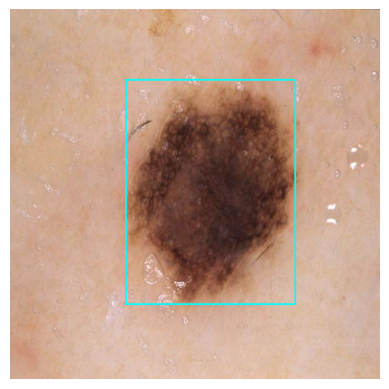

2026-06-04 17:07:03,091 - INFO - Saved masked image as masked_image.png
2026-06-04 17:07:03,095 - INFO - Bounding box for ISIC_0024323.jpg: x=0.096875, y=0.125, w=0.7234375, h=0.659375
2026-06-04 17:07:03,099 - DEBUG - Drawing rectangle on image: x1=62, y1=80, x2=525, y2=502
2026-06-04 17:07:03,095 - INFO - Bounding box for ISIC_0024323.jpg: x=0.096875, y=0.125, w=0.7234375, h=0.659375
2026-06-04 17:07:03,099 - DEBUG - Drawing rectangle on image: x1=62, y1=80, x2=525, y2=502


640 640


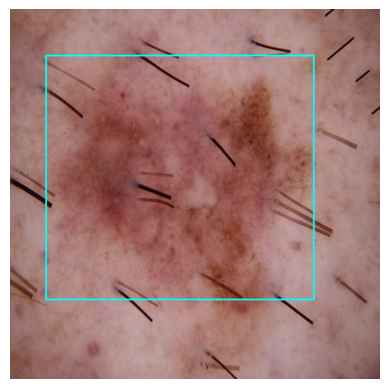

2026-06-04 17:07:03,358 - INFO - Saved masked image as masked_image.png
2026-06-04 17:07:03,361 - INFO - Bounding box for ISIC_0024316.jpg: x=0.1703125, y=0.0140625, w=0.65625, h=0.9328125
2026-06-04 17:07:03,361 - INFO - Bounding box for ISIC_0024316.jpg: x=0.1703125, y=0.0140625, w=0.65625, h=0.9328125
2026-06-04 17:07:03,363 - DEBUG - Drawing rectangle on image: x1=109, y1=9, x2=529, y2=606
2026-06-04 17:07:03,363 - DEBUG - Drawing rectangle on image: x1=109, y1=9, x2=529, y2=606


640 640


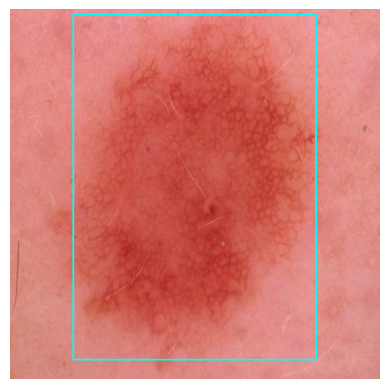

2026-06-04 17:07:03,659 - INFO - Saved masked image as masked_image.png
2026-06-04 17:07:03,660 - INFO - Finished showing images with masks.
2026-06-04 17:07:03,660 - INFO - Finished showing images with masks.


In [11]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

logger.info("Starting conversion of label files to mask images...")
pre_processor = PreProcessImage(label_dir, mask_dir, img_width, img_height)
pre_processor.convert_label_to_mask()
logger.info("Finished converting label files to mask images.")

logger.info("Starting to show images with masks...")
show_image_rect = ShowImageRect(img_dir, mask_dir)
show_image_rect.processImages()
logger.info("Finished showing images with masks.")

## Step 6: Execute Pipeline

This cell runs the complete pipeline:

1. **Convert Labels to Masks**
   - Reads all `.txt` files from the label directory
   - For each YOLO annotation, creates a binary mask
   - Saves masks as PNG images

2. **Display Results**
   - Processes first 3 images as demonstration
   - For each image:
     - Loads the original image
     - Loads corresponding mask
     - Extracts bounding box using contour detection
     - Overlays rectangle on original image
     - Displays with matplotlib
   
### Expected Output
- **Console Logs**: Processing status, warnings about malformed labels, bounding box coordinates
- **Mask Images**: PNG files in `masks_v2/` directory (white rectangles on black background)
- **Visual Displays**: Original images with yellow bounding box overlays